# Basic MUSIC Direction Finding with a UCA

This notebook implements the basic MUSIC direction-of-arrival algorithm for a six-element uniform circular array.

A single transmitter at a known direction is simulated first. Multiple noisy array snapshots are generated and used to calculate the covariance matrix. The covariance matrix is then decomposed into signal and noise components, and the MUSIC pseudospectrum is used to estimate the transmitter direction.

The processing sequence is

$$
\text{UCA Geometry}
\rightarrow
\text{Received Snapshots}
\rightarrow
\text{Covariance Matrix}
\rightarrow
\text{Eigendecomposition}
\rightarrow
\text{Noise Subspace}
\rightarrow
\text{MUSIC Spectrum}
\rightarrow
\text{AoA Estimate}.
$$

In [1]:
using LinearAlgebra
using Random
using Plots

## 1. UCA Geometry

The same six-element UCA geometry used in the previous simulations is retained.

The operating frequency is 433 MHz and the neighbouring antenna spacing is

$$
d = 0.4\lambda
$$

where

$$
\lambda = \frac{c}{f}.
$$

For a uniform circular array, the radius is

$$
R = \frac{d}{2\sin(\pi/N)}.
$$

In [10]:
# Speed of light and operating frequency
f = 433e6
c = 3e8

# Wavelength of the signal 433MHz
λ = c / f

# Number of outer UCA antennas
N = 6

# Neighnouring antenna spacing
d = 0.4 .* λ

# Radius of the circular array
R = d / (2 * sin.(π / N))

# Angular position of each antenna around the circle
phi = (0:N-1) .* (2π / N)

# Cartesian coordinates of each antenna
x = R .* cos.(phi)
y = R .* sin.(phi)

println("Wavelength = ", round(λ, digits=3), " m")
println("Spacing = ", round(d, digits=3), " m")
println("Radius = ", round(R, digits=3), " m")

Wavelength = 0.693 m
Spacing = 0.277 m
Radius = 0.277 m


## 2. True Signal Steering Vector

The transmitter is defined by two angles:

- azimuth $\phi_0$, measured around the UCA;
- elevation $\theta_0$, measured from the positive $z$-axis.

For antenna $i$, the spatial phase produced by a signal arriving from
$(\phi_0,\theta_0)$ is

$$
\psi_i
=
\frac{2\pi R}{\lambda}
\sin(\theta_0)
\cos(\phi_0-\phi_i).
$$

The six phase values form the steering vector

$$
\mathbf{a}(\phi_0,\theta_0)
=
\begin{bmatrix}
e^{j\psi_1} &
e^{j\psi_2} &
\cdots &
e^{j\psi_6}
\end{bmatrix}^{T}.
$$

MUSIC will later search over both azimuth and elevation to find the
steering vector that best matches the measured signal subspace.

In [47]:
# True transmitter direction
phi0_deg = 30
theta0_deg = 60

# Convert angles to radians
phi0 = deg2rad(phi0_deg)
theta0 = deg2rad(theta0_deg)

# Phase produced at each antenna
psi = (2π * R / λ) .* sin(theta0) .* cos.(phi0 .- phi)

# Steering vector for the true direction
a_true = exp.(im .* psi)

println("True azimuth = ", phi0_deg, "°")
println("True elevation = ", theta0_deg, "°")
println("Steering phases = ", round.(rad2deg.(angle.(a_true)), digits=2), "°")

True azimuth = 30°
True elevation = 60°
Steering phases = [108.0, 108.0, 0.0, -108.0, -108.0, -0.0]°


## 3. Generate Array Snapshots

MUSIC does not use only one antenna measurement. Several snapshots are collected so that the repeating spatial structure of the received signal can be separated from random noise.

For snapshot $k$,

$$
\mathbf{x}[k]
=
s[k]\mathbf{a}(\phi_0,\theta_0)
+
\mathbf{n}[k].
$$

Here:

- $\mathbf{a}(\phi_0,\theta_0)$ is the true steering vector;
- $s[k]$ is the complex signal value during snapshot $k$;
- $\mathbf{n}[k]$ is the noise across the six antennas;
- $\mathbf{x}[k]$ is the resulting received array snapshot.

The transmitter direction remains fixed, so the underlying spatial phase pattern stays the same between snapshots.

In [48]:
# Number of snapshots
K = 200

# Signal-to-noise ratio
SNR_dB = 10

# Signal power is 1, so calculate the required noise power
noise_power = 10^(-SNR_dB / 10)

# Store the 6 antenna measurements for every snapshot
X = zeros(ComplexF64, N, K)

Random.seed!(1)

for k in 1:K
    # Complex noise across the 6 antenna
    noise = sqrt(noise_power / 2) .* (randn(N) .+ im .* randn(N))
    
    # Received array snapshot
    X[:, k] = a_true + noise
end
println("size of X = ", size(X))

size of X = (6, 200)


## 4. Covariance Matrix

The covariance matrix summarises the average relationship between every antenna and every other antenna over all $K$ snapshots.

It is calculated as

$$
\mathbf{C}
=
\frac{1}{K}\mathbf{X}\mathbf{X}^{H}.
$$

Since $\mathbf{X}$ has 6 rows, the covariance matrix is a $6\times6$ matrix.

The diagonal entries mainly describe the signal power at each antenna, while the off-diagonal entries contain the relative complex relationships between different antennas.

In [49]:
# Covariance matrix: ()' = ()^H = conjugate transpose
C = (X * X') / K 

println("Size of C = ", size(C))

Size of C = (6, 6)


## 5. Eigendecomposition

The covariance matrix is decomposed into its eigenvalues and eigenvectors.

For each eigenvector $\mathbf{e}_i$,

$$
\mathbf{C}\mathbf{e}_i
=
\mu_i\mathbf{e}_i
$$

where:

- $\mathbf{e}_i$ is an eigenvector of the covariance matrix;
- $\mu_i$ is the corresponding eigenvalue.

An eigenvector represents a spatial pattern present in the covariance matrix, while its eigenvalue indicates how strongly that pattern is represented.

In MUSIC, the eigenvalues are used to separate the signal and noise subspaces. For one transmitter, we expect one eigenvalue to be much larger than the others. Its corresponding eigenvector represents the signal subspace, while the remaining eigenvectors form the noise subspace.

### Why is the covariance matrix Hermitian?

The covariance matrix was calculated as

$$
\mathbf{C}
=
\frac{1}{K}\mathbf{X}\mathbf{X}^{H}.
$$

Taking its Hermitian transpose gives

$$
\mathbf{C}^{H}
=
\left(
\frac{1}{K}\mathbf{X}\mathbf{X}^{H}
\right)^{H}
=
\frac{1}{K}\mathbf{X}\mathbf{X}^{H}
=
\mathbf{C}.
$$

Therefore,

$$
\boxed{\mathbf{C}^{H}=\mathbf{C}}
$$

which means that the covariance matrix is Hermitian.

A Hermitian matrix has real eigenvalues and orthogonal eigenvectors, which is useful for separating the signal and noise subspaces in MUSIC.

In [50]:
# Eigendecomposition of the covariance matrix[finding both the eigenvectors and eigenvalues]
eigC = eigen(Hermitian(C)) 

# Sort them from largest eigenvalue to smallest
order = sortperm(eigC.values, rev=true)

eigenvalues = eigC.values[order]
eigenvectors = eigC.vectors[:, order]

println("Eigenvalues and corresponding eigenvectors:")

for i in 1:N
    println()
    println("Eigenvalue ", i, " = ", eigenvalues[i])
    println("Eigenvector ", i, " = ")
    println(eigenvectors[:, i])
end

Eigenvalues and corresponding eigenvectors:

Eigenvalue 1 = 6.1580930014682735
Eigenvector 1 = 
ComplexF64[-0.1265099592620681 + 0.38284486667368584im, -0.12640967922219037 + 0.38455412831769614im, 0.40822134586388653 + 0.00792093908389351im, -0.12111078844625836 - 0.3900736162494761im, -0.13316092458676632 - 0.3923911795948468im, 0.4102784741298623 - 0.0im]

Eigenvalue 2 = 0.12247240329253133
Eigenvector 2 = 
ComplexF64[-0.3194195820002002 + 0.2164808885061931im, 0.5153417927062081 + 0.5489575340936877im, -0.2814726686819011 + 0.02877987004029097im, 0.14295716154133623 - 0.14249243274484677im, 0.29530258663630193 + 0.2268248183214595im, -0.15724666787539388 - 0.0im]

Eigenvalue 3 = 0.11998007712431968
Eigenvector 3 = 
ComplexF64[0.006787574524589141 - 0.5204691303365616im, 0.06402087637475888 - 0.04215803070338172im, -0.4219852440009904 - 0.323750546377344im, -0.18303805987967514 - 0.5118099482179775im, 0.15098850686765614 - 0.26306355615665844im, 0.2298946723103352 + 0.0im]

Eigenval

## 6. Noise Subspace

For one transmitter, the eigenvector corresponding to the largest
eigenvalue represents the signal subspace.

The remaining five eigenvectors form the noise subspace.

These noise eigenvectors are grouped into the matrix

$$
\mathbf{E}_n
=
\begin{bmatrix}
\mathbf{e}_2 &
\mathbf{e}_3 &
\mathbf{e}_4 &
\mathbf{e}_5 &
\mathbf{e}_6
\end{bmatrix}.
$$

The true steering vector should be approximately orthogonal to this
noise subspace:

$$
\mathbf{E}_n^H \mathbf{a}(\phi_0,\theta_0)
\approx
\mathbf{0}.
$$

MUSIC uses this property to find the transmitter direction.

In [51]:
# Noise subspace: eigenvectors corresponding to the 5 smallest eigenvalues
En = eigenvectors[:, 2:end]

println("Size of noise subspace = ", size(En))

Size of noise subspace = (6, 5)


## 7. Check the True Steering Vector Against the Noise Subspace

For the true transmitter direction, the steering vector should be approximately
orthogonal to all five noise eigenvectors.

This is checked using

$$
\mathbf{E}_n^H\mathbf{a}(\phi_0,\theta_0).
$$

If the steering vector is orthogonal to the noise subspace, the resulting
values should be close to zero.

They will not be exactly zero because the covariance matrix was estimated
from a finite number of noisy snapshots.

In [52]:
# Projection of the true steering vector onto the noise subspace
noise_projection_true = En' * a_true

println("Projection onto each noise eigenvector:")
println(round.(abs.(noise_projection_true), digits=4))

Projection onto each noise eigenvector:
[0.0135, 0.0086, 0.0079, 0.0165, 0.0227]


## 8. MUSIC Direction Search

MUSIC now tests possible azimuth and elevation angles.

For every candidate direction $(\phi,\theta)$:

1. calculate its steering vector $\mathbf{a}(\phi,\theta)$;
2. project it onto the noise subspace;
3. calculate the MUSIC pseudospectrum.

The MUSIC pseudospectrum is

$$
P_{\mathrm{MUSIC}}(\phi,\theta)
=
\frac{1}
{
\mathbf{a}^{H}(\phi,\theta)
\mathbf{E}_n
\mathbf{E}_n^{H}
\mathbf{a}(\phi,\theta)
}.
$$

At the correct direction, the steering vector is almost orthogonal to the
noise subspace. The denominator therefore becomes very small and the
MUSIC spectrum produces a large peak.

In [53]:
# Angles to test
phi_scan_deg = 0:1:359
theta_scan_deg = 0:1:90

# Store the MUSIC result for every tested direction
music_spectrum = zeros(length(theta_scan_deg), length(phi_scan_deg))

for theta_index in 1:length(theta_scan_deg)

    theta_test = deg2rad(theta_scan_deg[theta_index])

    for phi_index in 1:length(phi_scan_deg)

        phi_test = deg2rad(phi_scan_deg[phi_index])

        # Steering vector for this test direction
        psi_test = (2π * R / λ) .* sin(theta_test) .* cos.(phi_test .- phi)
        a_test = exp.(im .* psi_test)

        # MUSIC value
        noise_projection = En' * a_test
        music_spectrum[theta_index, phi_index] = 1 / sum(abs2, noise_projection)

    end
end
music_spectrum

91×360 Matrix{Float64}:
 0.169404  0.169404  0.169404  0.169404  …  0.169404  0.169404  0.169404
 0.170393  0.170404  0.170415  0.170425     0.170358  0.17037   0.170382
 0.171548  0.171575  0.171601  0.171626     0.171465  0.171493  0.171521
 0.172875  0.172922  0.172967  0.173011     0.172729  0.172779  0.172828
 0.174379  0.174451  0.174521  0.17459      0.174154  0.17423   0.174306
 0.176065  0.176168  0.176269  0.176367  …  0.175742  0.175852  0.175959
 0.177937  0.178078  0.178216  0.178351     0.177497  0.177647  0.177793
 0.180001  0.180187  0.18037   0.180548     0.179422  0.179618  0.179811
 0.182261  0.1825    0.182735  0.182965     0.181517  0.181769  0.182017
 0.184721  0.185022  0.185319  0.185609     0.183786  0.184102  0.184414
 0.187385  0.187759  0.188127  0.188488  …  0.18623   0.18662   0.187005
 0.190256  0.190714  0.191165  0.191608     0.188848  0.189323  0.189792
 0.193339  0.193892  0.194438  0.194975     0.191641  0.192213  0.192779
 ⋮                         

## 9. Estimate the Direction

The estimated direction is the azimuth and elevation where the MUSIC
pseudospectrum has its largest value.

$$
(\hat{\phi},\hat{\theta})
=
\operatorname*{arg\,max}_{\phi,\theta}
P_{\mathrm{MUSIC}}(\phi,\theta)
$$

In [54]:
# Find the largest MUSIC value
max_value, max_index = findmax(music_spectrum)

# Convert the matrix index back to angles
theta_est = theta_scan_deg[max_index[1]]
phi_est = phi_scan_deg[max_index[2]]

println("Estimated azimuth = ", phi_est, "°")
println("Estimated elevation = ", theta_est, "°")

max_index

Estimated azimuth = 30°
Estimated elevation = 60°


CartesianIndex(61, 31)

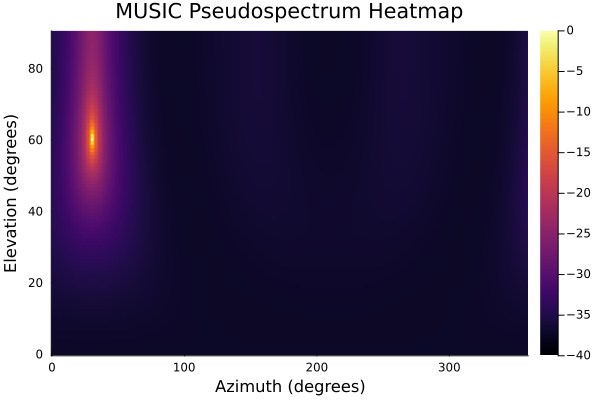

In [59]:
# Heatmap
heatmap(
    phi_scan_deg,
    theta_scan_deg,
    music_plot_dB,
    xlabel = "Azimuth (degrees)",
    ylabel = "Elevation (degrees)",
    title = "MUSIC Pseudospectrum Heatmap",
    clims = (floor_dB, 0)
)

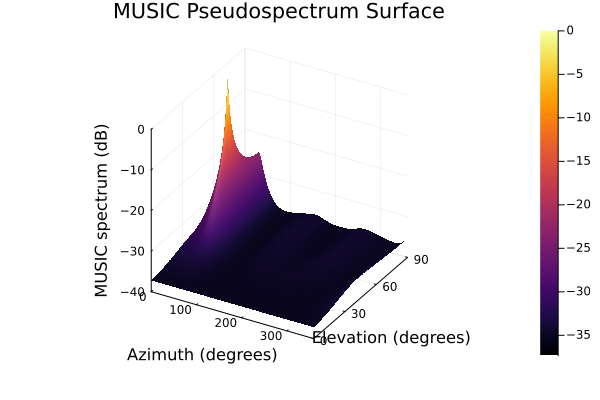

In [60]:
# 3D surface
surface(
    phi_scan_deg,
    theta_scan_deg,
    music_plot_dB,
    xlabel = "Azimuth (degrees)",
    ylabel = "Elevation (degrees)",
    zlabel = "MUSIC spectrum (dB)",
    title = "MUSIC Pseudospectrum Surface",
    zlims = (floor_dB, 0)
)